# JSBSim Trim and Elevator Doublet with PathSim

This notebook demonstrates how to embed a [JSBSim](https://github.com/JSBSim-Team/jsbsim)
flight dynamics model (FDM) directly inside a [PathSim](https://github.com/pathsim/pathsim)
block diagram using a `DynamicalFunction` block — without any additional wrapper library.

The example is adapted from
[test_pathsim_01_Trim_Elevator_Doublet.ipynb](https://github.com/agodemar/jsbsim/blob/master/examples/python/test_pathsim_01_Trim_Elevator_Doublet.ipynb)
and covers:

1. Instantiating and trimming a JSBSim FDM (Global 5000 business jet).
2. Wrapping the FDM step inside a PathSim `DynamicalFunction` block.
3. Assembling a block diagram that applies a **doublet elevator input** and records
   the angle-of-attack response.
4. Plotting the results.

**Prerequisites:** `jsbsim` and `pathsim` must be installed.

```bash
pip install jsbsim
pip install pathsim
```

**Previous notebook:** [03_pathsim_intro.ipynb](03_pathsim_intro.ipynb) – PathSim block-diagram basics.  
**Next notebook:** [05_pathsim_flight.ipynb](05_pathsim_flight.ipynb) – higher-level `pathsim-flight` integration.

## 1. Imports

In [1]:
# If running on Google Colab, install the required packages.

import sys

if 'google.colab' in sys.modules:
    print('Running on Google Colab \u2013 installing jsbsim, pathsim \u2026')
    !pip install jsbsim pathsim


In [2]:
import os
import xml.etree.ElementTree as ET

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import jsbsim
import pathsim

matplotlib.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.4})

# Suppress JSBSim console output
# jsbsim.FGJSBBase().debug_lvl = 0

print(f"JSBSim version  : {jsbsim.__version__}")
print(f"PathSim version : {pathsim.__version__}")

JSBSim version  : 1.3.0
PathSim version : 0.20.0


## 2. Initialize the JSBSim FDM

Instantiate an `FGFDMExec` object and load the **Global 5000** business-jet model
(`global5000`) from the JSBSim Python-package data directory.

In [3]:
AIRCRAFT_NAME = "global5000"

# Use the aircraft data bundled with the jsbsim Python package
fdm = jsbsim.FGFDMExec(jsbsim.get_default_root_dir())

fdm.set_debug_level(0) # Suppress verbose JSBSim console output

load_status = fdm.load_model(AIRCRAFT_NAME)

# Property manager gives direct node access (used later to read alpha)
pm = fdm.get_property_manager()

print(f"Aircraft loaded  : {AIRCRAFT_NAME}")
print(f"JSBSim root dir  : {fdm.get_root_dir()}")
print(f"Load status      : {load_status}")



     JSBSim Flight Dynamics Model v1.3.0 Apr  9 2026 10:00:08
            [JSBSim-ML v2.0]

JSBSim startup beginning ...


In file /home/vscode/.local/lib/python3.11/site-packages/jsbsim/aircraft/global5000/global5000.xml: line 917
  No property by the name aero/coefficient/CLalpha has been defined. This property will not be logged. You should check your configuration file.
Aircraft loaded  : global5000
JSBSim root dir  : /home/vscode/.local/lib/python3.11/site-packages/jsbsim
Load status      : True


## 3. Aircraft Parameters and Trim Conditions

Parse the aircraft XML to extract the empty weight and centre-of-gravity location,
then define payload, fuel, and initial flight conditions for the trim.

In [4]:
# Parse aircraft XML to get empty weight and CG
ac_xml_path = os.path.join(
    fdm.get_root_dir(), f"aircraft/{AIRCRAFT_NAME}/{AIRCRAFT_NAME}.xml"
)
ac_xml_root = ET.parse(ac_xml_path).getroot()

# Empty weight [lbs]
empty_weight = float(
    ac_xml_root.find("mass_balance/emptywt").text
)

# Original CG x-location [inches from construction-axes origin]
x_cg_0 = float(
    ac_xml_root.find("mass_balance/location/x").text
)

# --- Payload and fuel ---
payload_0     = 15172 / 2      # half payload [lb]
fuelmax       = 8097.63        # Global 5000 max fuel [lb]
fuel_per_tank = fuelmax / 2    # each of the three tanks loaded to half its capacity

# --- Initial flight conditions ---
speed_cas = 250.0   # calibrated airspeed [kts]
h_ft_0    = 15000.0 # altitude [ft]
gamma_0   = 0.0     # flight-path angle [deg]

weight_0 = empty_weight + payload_0 + fuel_per_tank * 3

print(f"Empty weight        : {empty_weight:.0f} lb")
print(f"Total weight (est.) : {weight_0:.0f} lb")
print(f"CG x (original)     : {x_cg_0:.2f} in")
print(f"Trim altitude       : {h_ft_0:.0f} ft")
print(f"Trim CAS            : {speed_cas:.0f} kts")

Empty weight        : 48235 lb
Total weight (est.) : 67967 lb
CG x (original)     : 790.82 in
Trim altitude       : 15000 ft
Trim CAS            : 250 kts


## 4. Level-Flight Trim

Apply the initial conditions, start the engines, and ask JSBSim's built-in trimmer
(`simulation/do_simple_trim`) to find the steady level-flight equilibrium.
The resulting elevator position and throttle are saved as the trim reference.

In [5]:
# Set engines running
fdm['propulsion/set-running'] = -1

# Initial conditions
fdm['ic/h-sl-ft']   = h_ft_0
fdm['ic/vc-kts']    = speed_cas
fdm['ic/gamma-deg'] = gamma_0

# Fuel load (three tanks)
fdm['propulsion/tank[0]/contents-lbs'] = fuel_per_tank
fdm['propulsion/tank[1]/contents-lbs'] = fuel_per_tank
fdm['propulsion/tank[2]/contents-lbs'] = fuel_per_tank

# Payload pointmass
fdm['inertia/pointmass-weight-lbs[0]'] = payload_0

# Initialise and trim
fdm.run_ic()
fdm.run()
fdm['simulation/do_simple_trim'] = 1
fdm.run()

# Trim results
trim_vc_kts       = fdm['velocities/vc-kts']
trim_alpha_deg    = fdm['aero/alpha-deg']
trim_elev_rad     = fdm['fcs/elevator-pos-rad']
trim_elev_deg     = fdm['fcs/elevator-pos-deg']
trim_elev_norm    = fdm['fcs/elevator-pos-norm']
throttle_cmd_0    = fdm['fcs/throttle-cmd-norm']

print("Trim results:")
print(f"  CAS               : {trim_vc_kts:.2f} kts")
print(f"  Angle of attack   : {trim_alpha_deg:.4f} deg")
print(f"=========")
print(f"  Elevator (rad)    : {trim_elev_rad:.6f} rad")
print(f"  Elevator (deg)    : {trim_elev_deg:.4f} deg")
print(f"  Elevator (norm)   : {trim_elev_norm:.6f}")
print(f"=========")
print(f"  Elevator Autopilot Cmd (norm) : {fdm['ap/elevator_cmd']:.6f}")
print(f"  Elevator Trim Tab Cmd (norm) : {fdm['fcs/elevator-cmd-norm']:.6f}")
print(f"=========")
print(f"  Throttle cmd norm : {throttle_cmd_0:.6f}")

Trim results:
  CAS               : 250.00 kts
  Angle of attack   : 4.3176 deg
  Elevator (rad)    : -0.051721 rad
  Elevator (deg)    : -2.9634 deg
  Elevator (norm)   : -0.147775
  Elevator Autopilot Cmd (norm) : -0.000000
  Elevator Trim Tab Cmd (norm) : 0.000000
  Throttle cmd norm : 0.772610


## 5. PathSim Block Diagram

The flight-dynamics model is embedded as a PathSim
[DynamicalFunction](https://docs.pathsim.org/pathsim/) block whose
**input** is the normalised elevator command and whose **output** is the
angle of attack in degrees.

The total elevator command is the sum of two sources:

| Block | Role |
|-------|------|
| `srcElevatorAtTrim` | Constant source — elevator position at trim |
| `srcStepElevator` | `StepSource` — doublet perturbation (±10 % of full deflection) |
| `addedElevatorSignals` | `Adder` — sums the two signals |
| `dynFunAircraft` | `DynamicalFunction` — calls `fdm.run()` and returns α |
| `ampElevatorNormalized` | `DynamicalFunction` — scales command × 100 for display |
| `sco` | `Scope` — records both channels for plotting |

The doublet shape: see code below

In [6]:
from pathsim import Simulation, Connection
from pathsim.blocks import DynamicalFunction, Source, StepSource, Adder, Scope

# -----------------------------------------------------------------------
# Aircraft block: receives elevator command, advances JSBSim by one step,
# and returns the angle of attack.
# -----------------------------------------------------------------------
def f_aircraft(u, t):
    # Hold throttle at trim power to isolate the elevator response
    fdm['fcs/throttle-cmd-norm'] = throttle_cmd_0
    # PathSim passes u as a 1-D array; recent numpy rejects float() on non-0-d arrays,
    # so .flat[0] reliably extracts the scalar regardless of array shape.
    fdm['fcs/elevator-cmd-norm'] = float(np.asarray(u).flat[0])
    fdm.run()
    return pm.get_node('aero/alpha-deg').get_double_value()

dynFunAircraft = DynamicalFunction(f_aircraft)

# -----------------------------------------------------------------------
# Signal sources
# -----------------------------------------------------------------------

# Constant: normalised elevator position at trim
def f_elevator_command_at_trim(t):
    return 0 # already set to: trim_elev_norm ... Why?

srcElevatorAtTrim = Source(f_elevator_command_at_trim)

# Doublet: −0.10 at t=10 s, 0 at t=11 s, +0.10 at t=12 s, 0 at t=13 s
srcStepElevator = StepSource(
    amplitude=[-0.1, 0, 0.1, 0],
    tau=[10, 11, 12, 13]
)

# -----------------------------------------------------------------------
# Signal processing blocks
# -----------------------------------------------------------------------

# Sum trim command and doublet perturbation
addedElevatorSignals = Adder('++')

# Scale elevator command × 100 so both traces fit on a similar y-scale
def f_gain_100x(u, t):
    return 100.0 * u

ampElevatorNormalized = DynamicalFunction(f_gain_100x)

# Scope records two channels: scaled elevator command and alpha
sco = Scope(labels=["Elevator Command (% of full deflection)", "Angle of Attack (deg)"])

# -----------------------------------------------------------------------
# Assemble the block diagram
# -----------------------------------------------------------------------
blocks = [
    srcElevatorAtTrim,
    srcStepElevator,
    addedElevatorSignals,
    dynFunAircraft,
    ampElevatorNormalized,
    sco,
]

connections = [
    Connection(srcElevatorAtTrim,      addedElevatorSignals[0]),
    Connection(srcStepElevator,        addedElevatorSignals[1]),
    Connection(addedElevatorSignals,   dynFunAircraft),
    Connection(addedElevatorSignals,   ampElevatorNormalized),
    Connection(ampElevatorNormalized,  sco[0]),
    Connection(dynFunAircraft,         sco[1]),
]

# -----------------------------------------------------------------------
# Run the simulation for 40 s with a JSBSim standard dt (60 Hz)
# -----------------------------------------------------------------------
sim = Simulation(blocks, connections, 
                 dt=fdm.get_delta_t(), 
                 log=True)

print("Running 40-second simulation …")
sim.run(40.0)
print("Done.")

17:50:56 - INFO - LOGGING (log: True)
17:50:56 - INFO - BLOCKS (total: 6, dynamic: 0, static: 6, eventful: 1)
17:50:56 - INFO - GRAPH (nodes: 6, edges: 6, alg. depth: 3, loop depth: 0, runtime: 0.077ms)
Running 40-second simulation …
17:50:56 - INFO - STARTING -> TRANSIENT (Duration: 40.00s)
17:50:57 - INFO - --------------------   1% | 0.0s<1.4s | 3331.3 it/s
17:50:57 - INFO - ####----------------  20% | 0.2s<0.3s | 11053.6 it/s
17:50:57 - INFO - ########------------  40% | 0.3s<0.4s | 6985.4 it/s
17:50:57 - INFO - ############--------  60% | 0.4s<0.2s | 11007.4 it/s
17:50:57 - INFO - ################----  80% | 0.5s<0.1s | 11118.7 it/s
17:50:57 - INFO - #################### 100% | 0.6s<--:-- | 11509.0 it/s
17:50:57 - INFO - FINISHED -> TRANSIENT (total steps: 4801, successful: 4801, runtime: 585.16 ms)
Done.


## 6. Simulation Results

The upper panel shows the normalised elevator command (scaled to percent of full
deflection) and the lower panel shows the resulting angle-of-attack response.

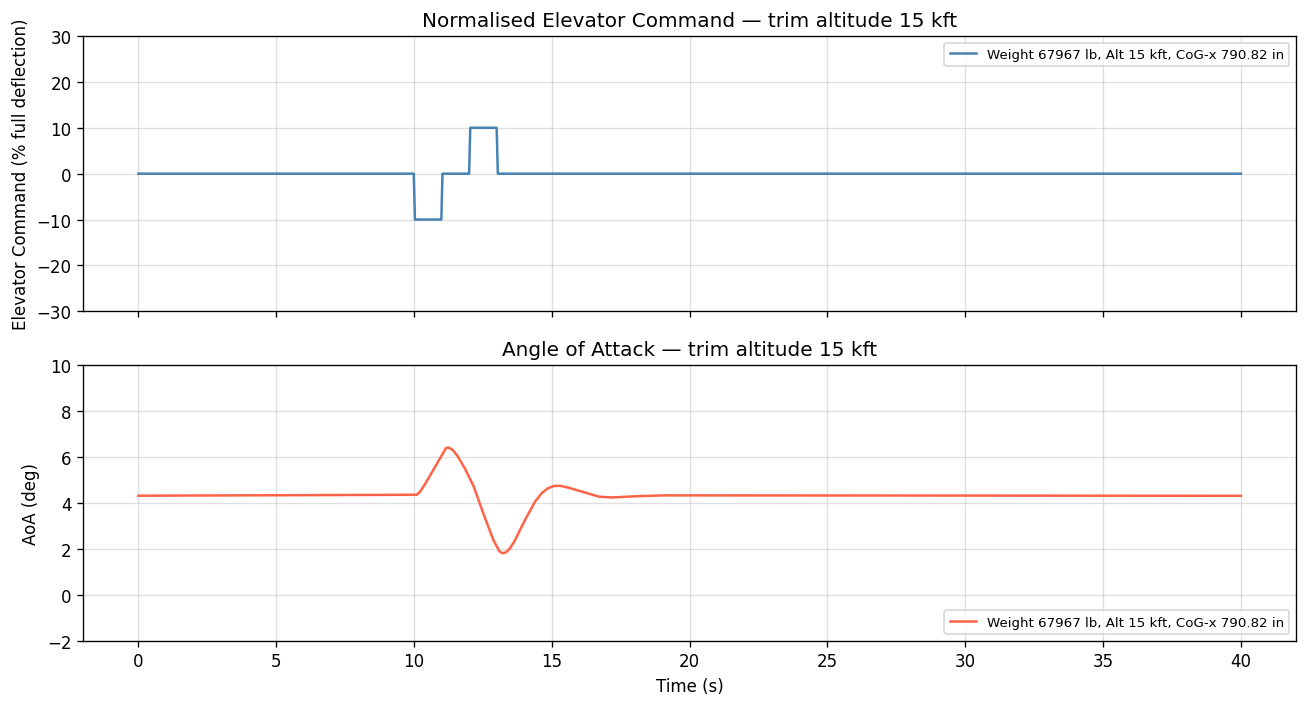

In [7]:
%matplotlib inline

t_rec   = sco.recording_time
data    = np.array(sco.recording_data[:])

label = (
    f"Weight {weight_0:.0f} lb, "
    f"Alt {h_ft_0/1000:.0f} kft, "
    f"CoG-x {x_cg_0:.2f} in"
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

ax1.plot(t_rec, data[:, 0], color='steelblue', linewidth=1.5, label=label)
ax1.set_title(
    f"Normalised Elevator Command — trim altitude {h_ft_0/1000:.0f} kft"
)
ax1.set_ylabel('Elevator Command (% full deflection)')
ax1.set_ylim(-30, 30)
ax1.legend(loc='upper right', fontsize=8)

ax2.plot(t_rec, data[:, 1], color='tomato', linewidth=1.5, label=label)
ax2.set_title(
    f"Angle of Attack — trim altitude {h_ft_0/1000:.0f} kft"
)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('AoA (deg)')
ax2.set_ylim(-2, 10)
ax2.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

## Summary

In this notebook you:

1. **Initialised** a JSBSim FDM for the Global 5000 business jet using the data
   bundled with the `jsbsim` Python package.
2. **Trimmed** the aircraft to steady level flight at 15 000 ft / 250 KCAS.
3. **Wrapped** the JSBSim step function inside a PathSim `DynamicalFunction`
   block — no additional library required.
4. **Built a block diagram** that superimposes a doublet elevator perturbation on
   the trim elevator command and records the angle-of-attack response.
5. **Plotted** the two-channel scope output.

**Next:** [05_pathsim_flight.ipynb](05_pathsim_flight.ipynb) – using the
higher-level `pathsim-flight` library (`JSBSimWrapper`, `ISAtmosphere`) to build
a closed-loop altitude-hold autopilot.